<a href="https://colab.research.google.com/github/diana499/BAESANDIANAlab7/blob/master/proiectnouBigData.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proiect Fundamente Big Data  
## Predicția bolilor cardiovasculare folosind Machine Learning și procesul KDD

În acest proiect este utilizat setul de date Heart Disease Dataset pentru a construi modele de clasificare care prezic dacă un pacient prezintă sau nu risc de boală cardiovasculară.

Procesul urmat este KDD:
1. Selecția datelor
2. Preprocesarea datelor
3. Transformarea datelor
4. Antrenarea modelelor
5. Validarea modelelor
6. Testarea finală
7. Interpretarea rezultatelor

Modelele folosite:
- Logistic Regression
- Decision Tree
- Random Forest
- SVM
- Gaussian Naive Bayes


# 1.IMPORTUL BIBLIOTECILOR

În această etapă sunt importate toate bibliotecile necesare pentru manipularea datelor, vizualizare, preprocesare, antrenarea modelelor și evaluarea performanței.

In [10]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive, files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

#2.CONECTAREA LA GOOGLE DRIVE
Această celulă permite accesul notebook-ului la fișierele stocate în Google Drive.


In [11]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

df = pd.read_csv("heart.csv")

print("Dataset încărcat cu succes!")
df.head()

Saving heart.csv to heart (3).csv
Dataset încărcat cu succes!


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


#3.ÎNCĂRCAREA DATASETULUI

În această etapă este încărcat setul de date utilizat în proiect.

In [12]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

df = pd.read_csv("heart.csv")

print("Dataset încărcat cu succes!")
df.head()

Saving heart.csv to heart (4).csv
Dataset încărcat cu succes!


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


# 4.AFIȘAREA PRIMELOR OBSERVAȚII

Sunt afișate primele înregistrări pentru a înțelege structura datelor.

In [13]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


# 5.ANALIZA GENERALĂ A DATASETULUI

Se verifică tipurile de date, numărul de observații și existența valorilor lipsă.

In [14]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB
None


# 6.STATISTICI DESCRIPTIVE

Se calculează statistici precum media, minimul, maximul și deviația standard.

In [15]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


# 7.VERIFICAREA VALORILOR LIPSĂ

In [16]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


# 8.ELIMINAREA DUPLICATELOR

Se elimină eventualele înregistrări duplicate.

In [17]:
print("Înainte:", df.shape)

df.drop_duplicates(inplace=True)

print("După:", df.shape)

Înainte: (1025, 14)
După: (302, 14)


# 9.DISTRIBUȚIA CLASELOR

Se verifică distribuția pacienților cu și fără boală cardiovasculară.

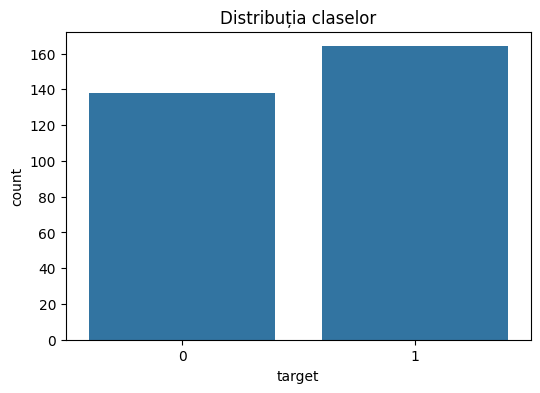

In [18]:
plt.figure(figsize=(6,4))

sns.countplot(x='target', data=df)

plt.title("Distribuția claselor")

plt.show()

# 10.MATRICEA DE CORELAȚII

Această analiză evidențiază relațiile dintre variabile.

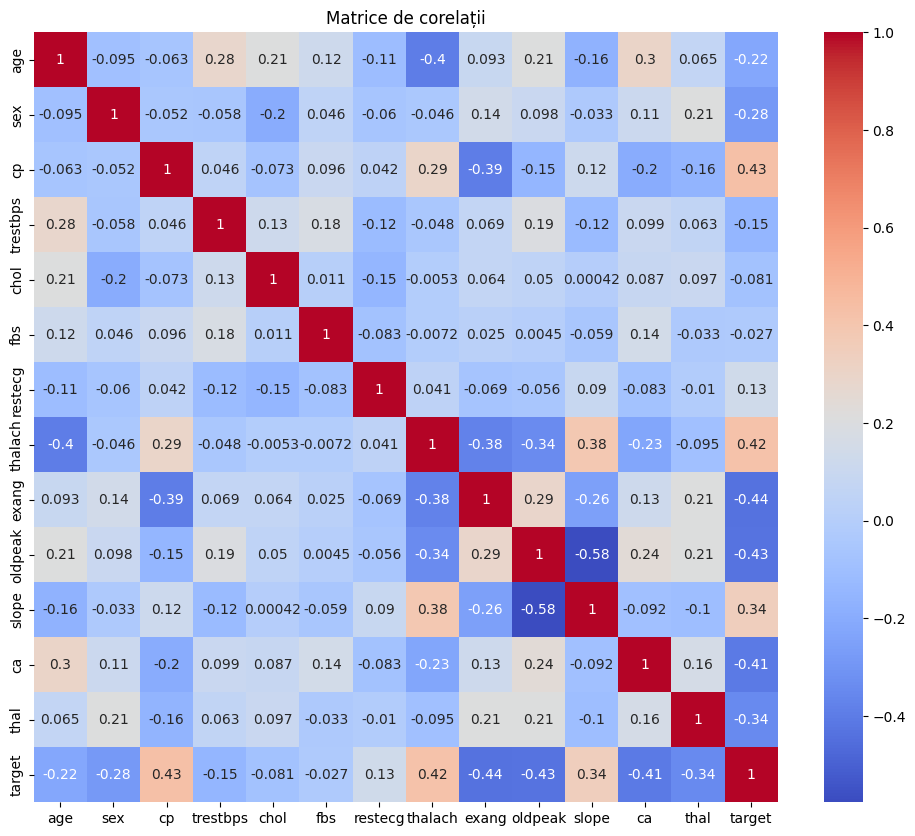

In [19]:
plt.figure(figsize=(12,10))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Matrice de corelații")

plt.show()

# Verificarea outlierilor prin boxplot

Outlierii au fost analizați vizual prin boxplot. Deoarece datasetul este medical, valorile extreme nu au fost eliminate automat, întrucât acestea pot reprezenta cazuri reale importante

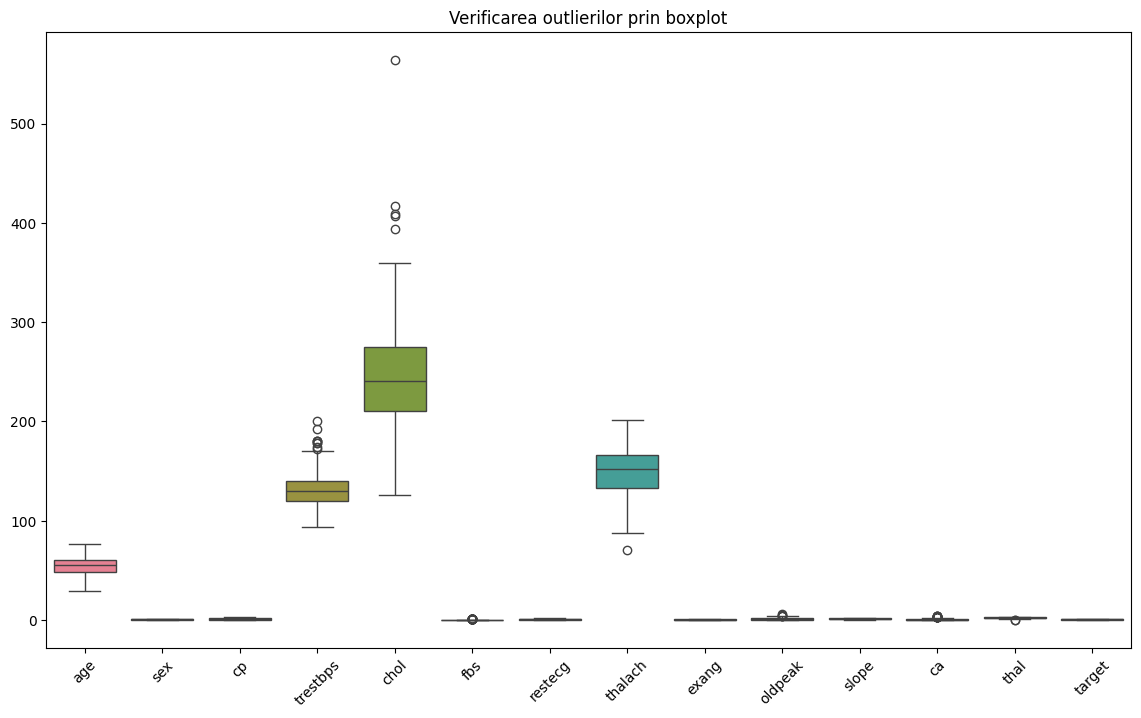

In [33]:
plt.figure(figsize=(14, 8))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.title("Verificarea outlierilor prin boxplot")
plt.show()

# 11.DEFINIREA VARIABILELOR

Se separă variabilele explicative de variabila țintă.

In [20]:
X = df.drop("target", axis=1)

y = df["target"]

feature_names = X.columns

# 12.ÎMPĂRȚIREA DATELOR

Datele sunt împărțite în:

70% antrenare
15% validare
15% testare

In [21]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (211, 13)
Validation: (45, 13)
Test: (46, 13)


# 13.DEFINIREA MODELELOR

Sunt definite cele cinci modele care vor fi comparate.

In [22]:
models = {

    "Logistic Regression": Pipeline([
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000))
    ]),

    "Decision Tree": Pipeline([
        ("imputer", SimpleImputer(strategy="mean")),
        ("model", DecisionTreeClassifier(
            max_depth=4,
            min_samples_leaf=3,
            random_state=42
        ))
    ]),

    "Random Forest": Pipeline([
        ("imputer", SimpleImputer(strategy="mean")),
        ("model", RandomForestClassifier(
            n_estimators=100,
            max_depth=5,
            random_state=42
        ))
    ]),

    "SVM": Pipeline([
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler()),
        ("model", SVC(
            kernel='rbf',
            probability=True
        ))
    ]),

    "Gaussian Naive Bayes": Pipeline([
        ("imputer", SimpleImputer(strategy="mean")),
        ("model", GaussianNB())
    ])
}

# 14.FUNCȚIE DE EVALUARE A MODELELOR

Această funcție calculează metricile de performanță pentru fiecare model: Accuracy, Precision, Recall, F1-Score și ROC-AUC. De asemenea, afișează matricea de confuzie și curba ROC.

In [23]:
def evaluate_model(model, X_data, y_data, dataset_name, model_name):
    y_pred = model.predict(X_data)

    y_prob = model.predict_proba(X_data)[:, 1]

    acc = accuracy_score(y_data, y_pred)
    prec = precision_score(y_data, y_pred, zero_division=0)
    rec = recall_score(y_data, y_pred, zero_division=0)
    f1 = f1_score(y_data, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_data, y_prob)

    print("\n===================================")
    print(model_name, "-", dataset_name)
    print("===================================")

    print("Accuracy:", round(acc, 4))
    print("Precision:", round(prec, 4))
    print("Recall:", round(rec, 4))
    print("F1 Score:", round(f1, 4))
    print("ROC-AUC:", round(roc_auc, 4))

    print("\nClassification Report:")
    print(classification_report(y_data, y_pred, zero_division=0))

    cm = confusion_matrix(y_data, y_pred)

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title("Matrice de confuzie - " + model_name + " - " + dataset_name)
    plt.xlabel("Predicție")
    plt.ylabel("Valoare reală")
    plt.show()

    fpr, tpr, thresholds = roc_curve(y_data, y_prob)

    plt.figure(figsize=(6, 5))
    plt.plot(
        fpr,
        tpr,
        label="AUC = " + str(round(roc_auc, 2))
    )

    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--"
    )

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Curba ROC - " + model_name + " - " + dataset_name)
    plt.legend()
    plt.show()

    return {
        "Model": model_name,
        "Set": dataset_name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    }

# 15.ANTRENAREA ȘI VALIDAREA MODELELOR

În această etapă fiecare model este antrenat pe setul de antrenare și evaluat pe setul de validare. Setul de validare ajută la alegerea celui mai bun model.


Se antrenează modelul: Logistic Regression

Logistic Regression - Validation
Accuracy: 0.8222
Precision: 0.7667
Recall: 0.9583
F1 Score: 0.8519
ROC-AUC: 0.9187

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.67      0.78        21
           1       0.77      0.96      0.85        24

    accuracy                           0.82        45
   macro avg       0.85      0.81      0.81        45
weighted avg       0.84      0.82      0.82        45



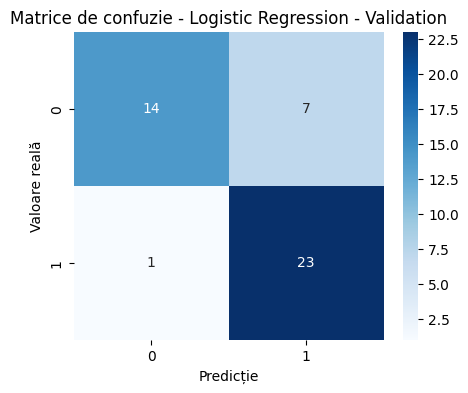

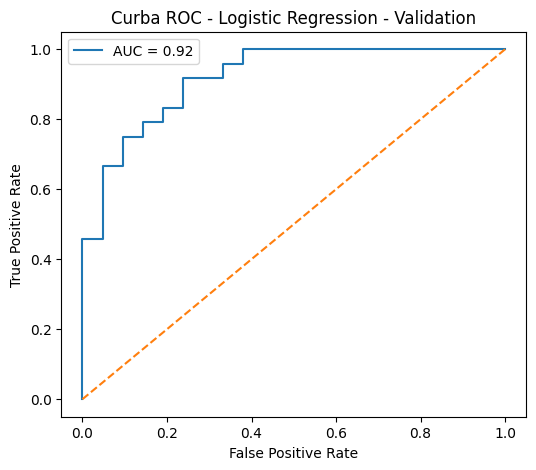


Se antrenează modelul: Decision Tree

Decision Tree - Validation
Accuracy: 0.7556
Precision: 0.7407
Recall: 0.8333
F1 Score: 0.7843
ROC-AUC: 0.8026

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.67      0.72        21
           1       0.74      0.83      0.78        24

    accuracy                           0.76        45
   macro avg       0.76      0.75      0.75        45
weighted avg       0.76      0.76      0.75        45



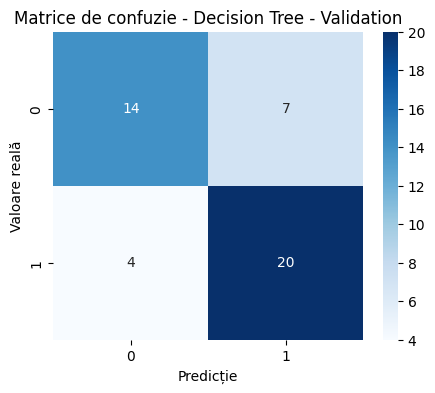

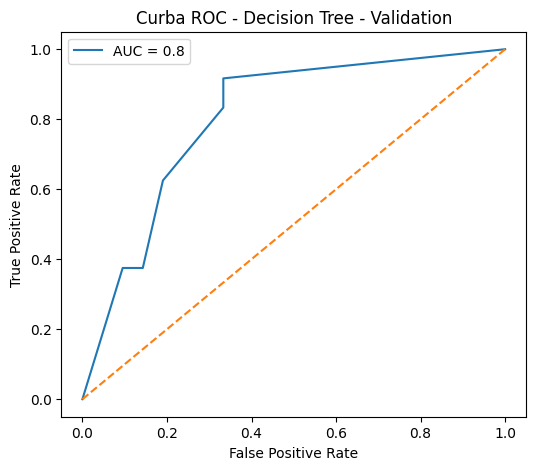


Se antrenează modelul: Random Forest

Random Forest - Validation
Accuracy: 0.8444
Precision: 0.7931
Recall: 0.9583
F1 Score: 0.8679
ROC-AUC: 0.9067

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.71      0.81        21
           1       0.79      0.96      0.87        24

    accuracy                           0.84        45
   macro avg       0.87      0.84      0.84        45
weighted avg       0.86      0.84      0.84        45



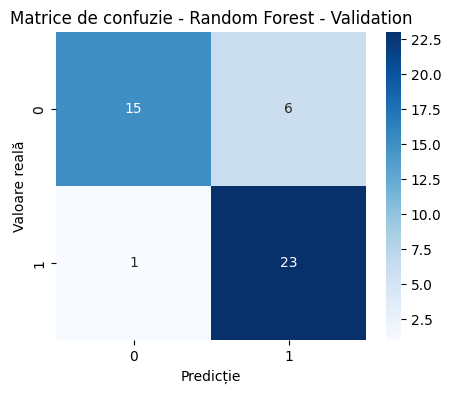

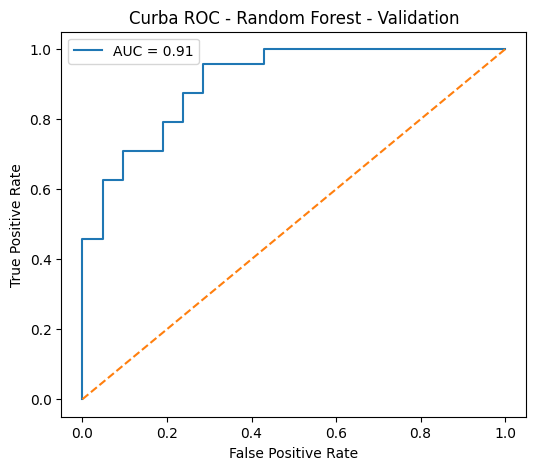


Se antrenează modelul: SVM

SVM - Validation
Accuracy: 0.8
Precision: 0.7586
Recall: 0.9167
F1 Score: 0.8302
ROC-AUC: 0.8948

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.67      0.76        21
           1       0.76      0.92      0.83        24

    accuracy                           0.80        45
   macro avg       0.82      0.79      0.79        45
weighted avg       0.81      0.80      0.80        45



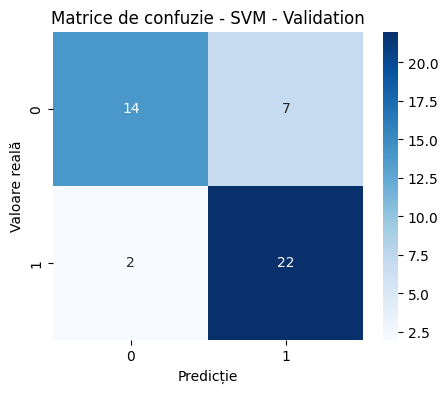

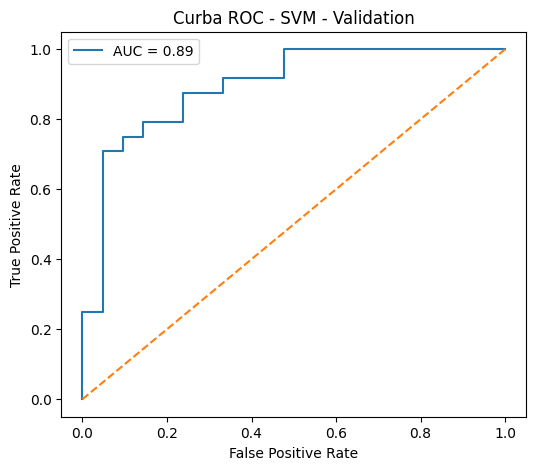


Se antrenează modelul: Gaussian Naive Bayes

Gaussian Naive Bayes - Validation
Accuracy: 0.7778
Precision: 0.7692
Recall: 0.8333
F1 Score: 0.8
ROC-AUC: 0.9107

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.71      0.75        21
           1       0.77      0.83      0.80        24

    accuracy                           0.78        45
   macro avg       0.78      0.77      0.78        45
weighted avg       0.78      0.78      0.78        45



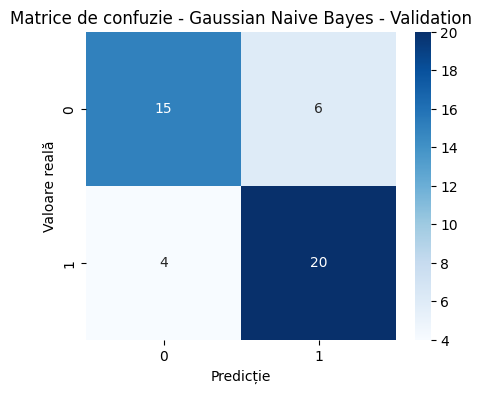

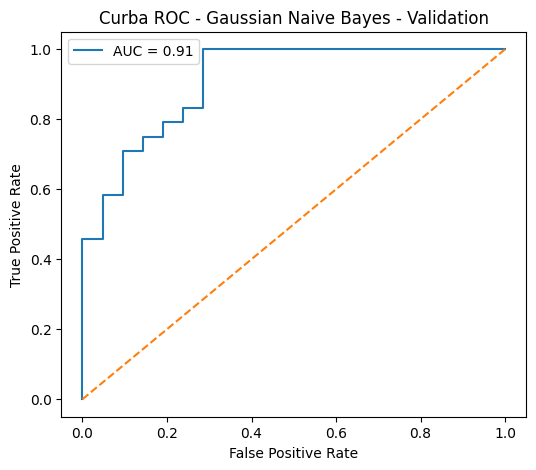


REZULTATE PE SETUL DE VALIDARE


,Model,Set,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,Validation,0.822222,0.766667,0.958333,0.851852,0.918651
1,Decision Tree,Validation,0.755556,0.740741,0.833333,0.784314,0.802579
2,Random Forest,Validation,0.844444,0.793103,0.958333,0.867925,0.906746
3,SVM,Validation,0.800000,0.758621,0.916667,0.830189,0.894841
4,Gaussian Naive Bayes,Validation,0.777778,0.769231,0.833333,0.800000,0.910714


In [24]:
validation_results = []

for name, model in models.items():

    print("\nSe antrenează modelul:", name)

    model.fit(X_train, y_train)

    result = evaluate_model(
        model,
        X_val,
        y_val,
        "Validation",
        name
    )

    validation_results.append(result)

validation_df = pd.DataFrame(validation_results)

print("\n==============================")
print("REZULTATE PE SETUL DE VALIDARE")
print("==============================")

display(validation_df)

# 16.ALEGEREA CELUI MAI BUN MODEL

Cel mai bun model este ales în funcție de valoarea F1-Score de pe setul de validare.

In [25]:
best_row = validation_df.sort_values(
    by="F1 Score",
    ascending=False
).iloc[0]

best_model_name = best_row["Model"]

best_model = models[best_model_name]

print("\n==============================")
print("CEL MAI BUN MODEL PE VALIDARE")
print("==============================")

print("Model ales:", best_model_name)

display(pd.DataFrame([best_row]))


CEL MAI BUN MODEL PE VALIDARE
Model ales: Random Forest


,Model,Set,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,Random Forest,Validation,0.844444,0.793103,0.958333,0.867925,0.906746


# 17.TESTAREA FINALĂ A CELUI MAI BUN MODEL

Modelul ales pe baza validării este evaluat final pe setul de testare. Acest set nu a fost folosit la antrenare sau selecție.


Random Forest - Test
Accuracy: 0.6957
Precision: 0.7895
Recall: 0.6
F1 Score: 0.6818
ROC-AUC: 0.8362

Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.81      0.71        21
           1       0.79      0.60      0.68        25

    accuracy                           0.70        46
   macro avg       0.71      0.70      0.70        46
weighted avg       0.72      0.70      0.69        46



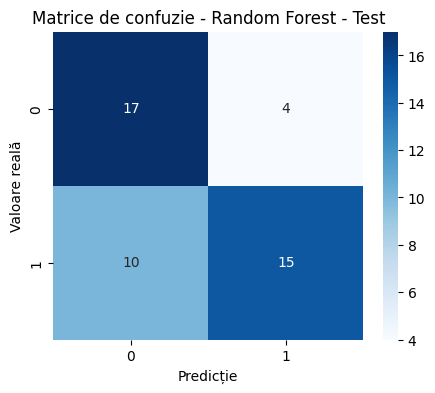

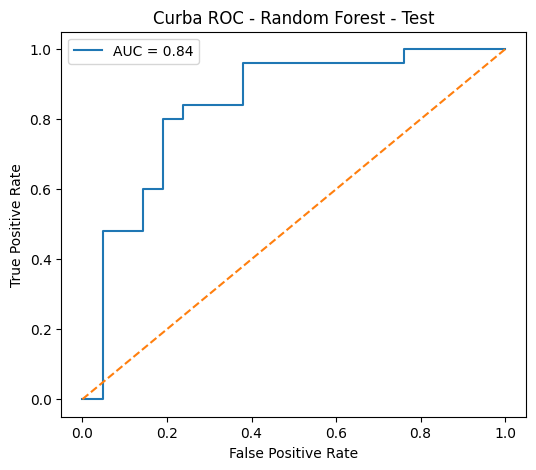


REZULTAT FINAL PE SETUL DE TEST


,Model,Set,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,Test,0.695652,0.789474,0.6,0.681818,0.83619


In [26]:
test_result = evaluate_model(
    best_model,
    X_test,
    y_test,
    "Test",
    best_model_name
)

test_df = pd.DataFrame([test_result])

print("\n==============================")
print("REZULTAT FINAL PE SETUL DE TEST")
print("==============================")

display(test_df)

# 18.COMPARAREA MODELELOR

Sunt comparate vizual modelele pe baza metricilor principale.

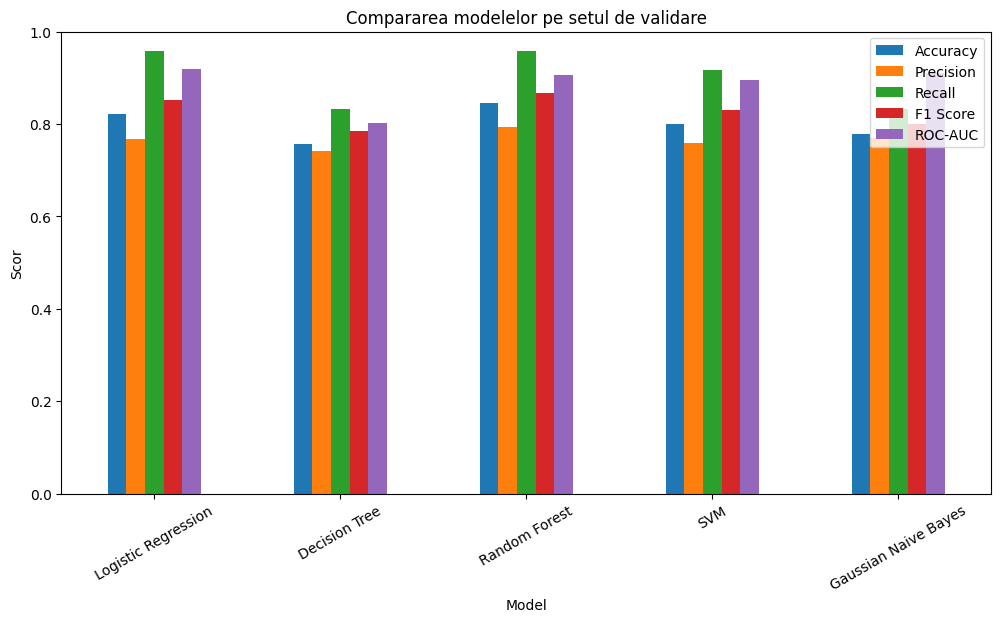

In [27]:
validation_df.set_index("Model")[[
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC"
]].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Compararea modelelor pe setul de validare")
plt.ylabel("Scor")
plt.xticks(rotation=30)
plt.ylim(0, 1)
plt.show()

## 19.COEFICIENȚII REGRESIEI LOGISTICE

Această celulă afișează coeficienții modelului Logistic Regression. Coeficienții arată influența fiecărei variabile asupra predicției.


COEFICIENȚII MODELULUI LOGISTIC REGRESSION


,Caracteristică,Coeficient
2,cp,1.196198
1,sex,-0.863832
7,thalach,0.860372
11,ca,-0.748629
12,thal,-0.550247
9,oldpeak,-0.483331
8,exang,-0.391052
3,trestbps,-0.347867
5,fbs,-0.320042
10,slope,0.314324


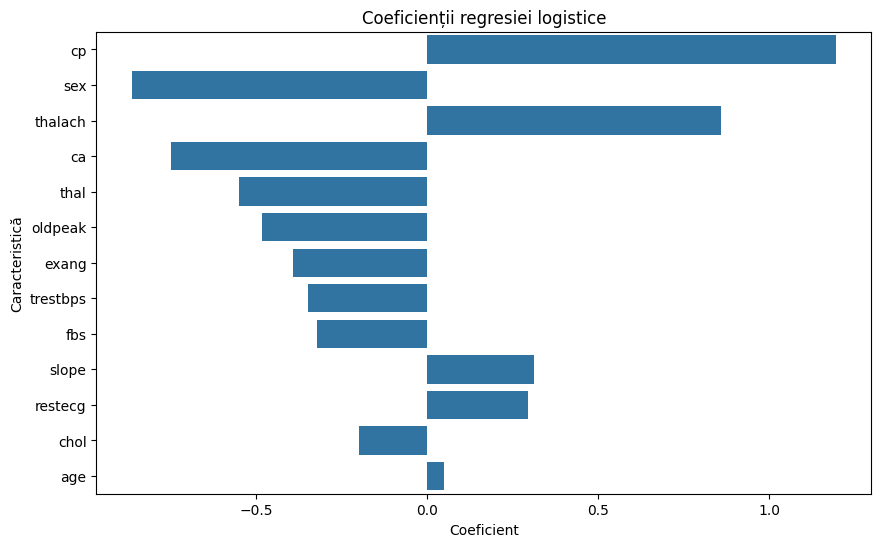

In [28]:
logistic_model = models["Logistic Regression"]

logistic_classifier = logistic_model.named_steps["model"]

coefficients = pd.DataFrame({
    "Caracteristică": feature_names,
    "Coeficient": logistic_classifier.coef_[0]
})

coefficients["Valoare absolută"] = coefficients["Coeficient"].abs()

coefficients = coefficients.sort_values(
    by="Valoare absolută",
    ascending=False
)

print("\n==============================")
print("COEFICIENȚII MODELULUI LOGISTIC REGRESSION")
print("==============================")

display(coefficients[["Caracteristică", "Coeficient"]])

plt.figure(figsize=(10, 6))

sns.barplot(
    data=coefficients,
    x="Coeficient",
    y="Caracteristică"
)

plt.title("Coeficienții regresiei logistice")
plt.xlabel("Coeficient")
plt.ylabel("Caracteristică")
plt.show()

# 20.ARBORE DE DECIZIE RAMIFICAT CU FRUNZE

Această celulă afișează arborele de decizie, cu ramificații și frunze. Frunzele reprezintă deciziile finale ale modelului.

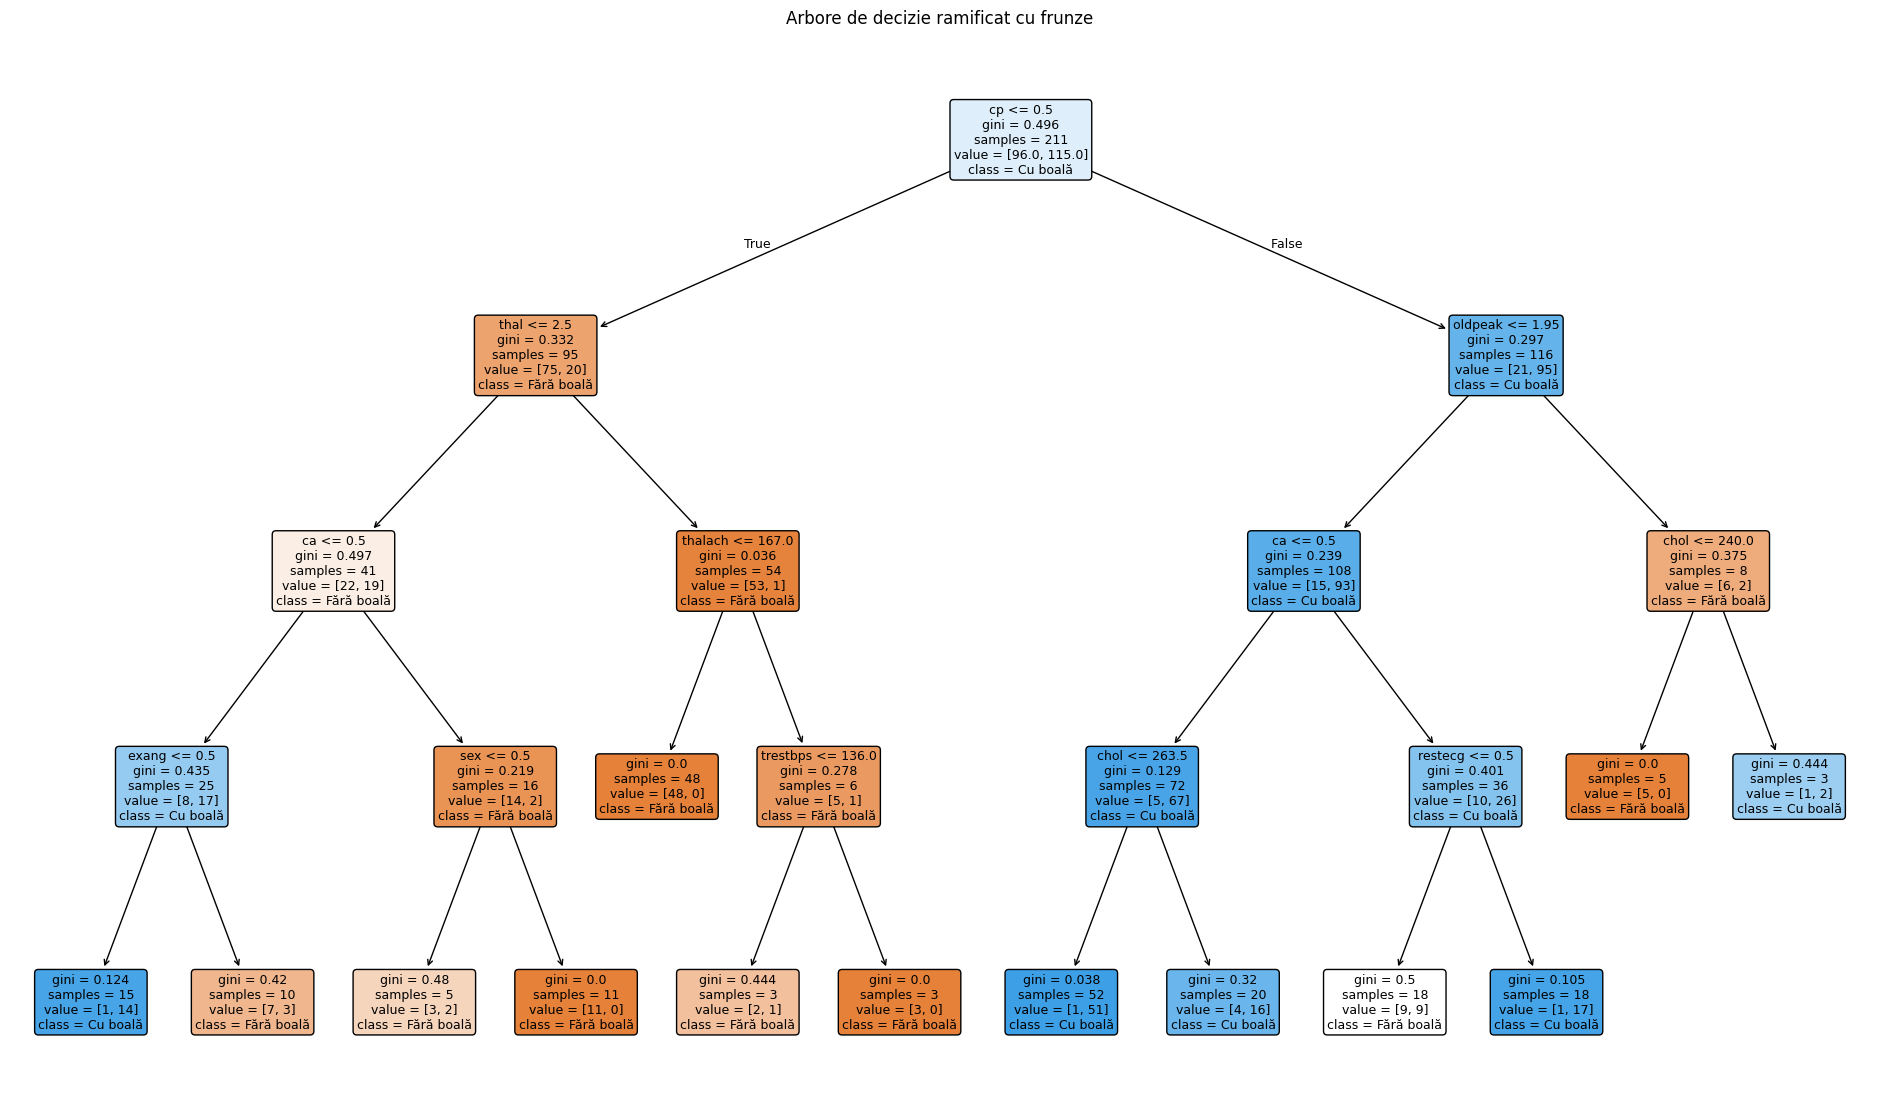

In [29]:
decision_tree_model = models["Decision Tree"]

tree_classifier = decision_tree_model.named_steps["model"]

plt.figure(figsize=(24, 14))

plot_tree(
    tree_classifier,
    feature_names=feature_names,
    class_names=["Fără boală", "Cu boală"],
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title("Arbore de decizie ramificat cu frunze")
plt.show()

# 21.IMPORTANȚA VARIABILELOR ÎN RANDOM FOREST

Această celulă arată care variabile au avut cea mai mare importanță în modelul Random Forest.


IMPORTANȚA VARIABILELOR - RANDOM FOREST


,Caracteristică,Importanță
2,cp,0.224318
7,thalach,0.133154
9,oldpeak,0.115018
12,thal,0.114266
11,ca,0.094701
8,exang,0.068514
0,age,0.068028
3,trestbps,0.050021
4,chol,0.043527
1,sex,0.038947


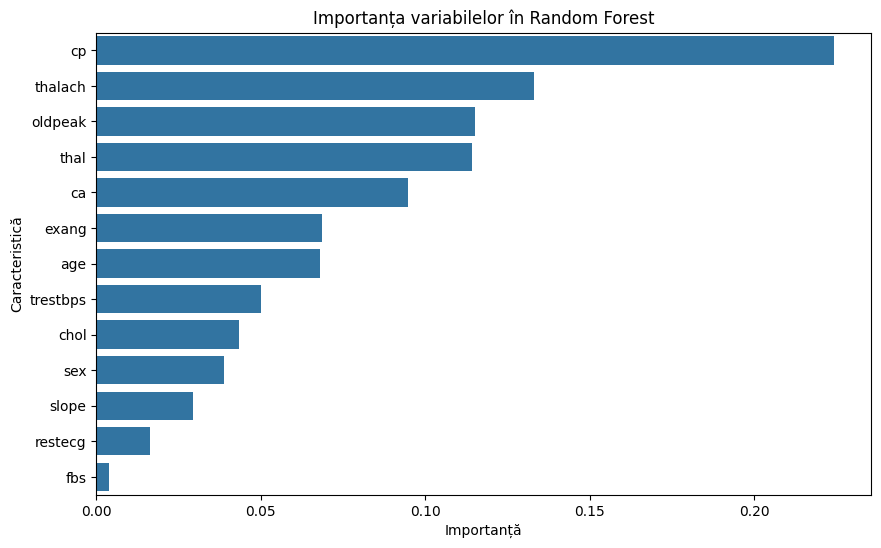

In [30]:
random_forest_model = models["Random Forest"]

rf_classifier = random_forest_model.named_steps["model"]

feature_importance = pd.DataFrame({
    "Caracteristică": feature_names,
    "Importanță": rf_classifier.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importanță",
    ascending=False
)

print("\n==============================")
print("IMPORTANȚA VARIABILELOR - RANDOM FOREST")
print("==============================")

display(feature_importance)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x="Importanță",
    y="Caracteristică"
)

plt.title("Importanța variabilelor în Random Forest")
plt.xlabel("Importanță")
plt.ylabel("Caracteristică")
plt.show()

# 22.INTERPRETAREA REZULTATELOR

Această celulă generează automat un scurt text interpretativ pe baza celui mai bun model ales.

In [31]:
print("\n==============================")
print("INTERPRETAREA REZULTATELOR")
print("==============================")

print("Cel mai bun model pe setul de validare este:", best_model_name)

print(
    "Modelul a fost ales pe baza scorului F1, deoarece această metrică "
    "ține cont atât de Precision, cât și de Recall."
)

print(
    "În context medical, Recall este foarte important deoarece este necesar "
    "să identificăm cât mai mulți pacienți care pot avea boală cardiovasculară."
)

print(
    "Setul de testare a fost folosit doar la final, pentru a estima performanța "
    "reală a modelului pe date necunoscute."
)


INTERPRETAREA REZULTATELOR
Cel mai bun model pe setul de validare este: Random Forest
Modelul a fost ales pe baza scorului F1, deoarece această metrică ține cont atât de Precision, cât și de Recall.
În context medical, Recall este foarte important deoarece este necesar să identificăm cât mai mulți pacienți care pot avea boală cardiovasculară.
Setul de testare a fost folosit doar la final, pentru a estima performanța reală a modelului pe date necunoscute.


# 23.CONCLUZIE FINALĂ

Această celulă oferă concluzia finală a proiectului.

In [32]:
print("\n==============================")
print("CONCLUZIE FINALĂ")
print("==============================")

print("În cadrul proiectului a fost aplicat procesul KDD complet.")
print("Au fost realizate selecția datelor, preprocesarea, transformarea, antrenarea, validarea și testarea modelelor.")
print("Au fost comparate mai multe modele de Machine Learning pentru clasificarea pacienților.")
print("Modelul final a fost ales pe baza performanței pe setul de validare.")
print("Proiectul include și interpretabilitate prin coeficienții regresiei logistice, arborele de decizie și importanța variabilelor Random Forest.")
print("PROIECT FINALIZAT CU SUCCES!")


CONCLUZIE FINALĂ
În cadrul proiectului a fost aplicat procesul KDD complet.
Au fost realizate selecția datelor, preprocesarea, transformarea, antrenarea, validarea și testarea modelelor.
Au fost comparate mai multe modele de Machine Learning pentru clasificarea pacienților.
Modelul final a fost ales pe baza performanței pe setul de validare.
Proiectul include și interpretabilitate prin coeficienții regresiei logistice, arborele de decizie și importanța variabilelor Random Forest.
PROIECT FINALIZAT CU SUCCES!
